#### Borough 및 동네별 매물 현황 (공급 분석)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../공유/final_cleaned_airbnb.csv')
df.shape

(19861, 60)

In [4]:
!pip install seaborn

In [5]:
#점유율 = 숙소가 1년 중 얼마나 예약되어 있었는가?
df['occupancy_rate'] = df['estimated_occupancy_l365d'] / 365
df['occupancy_rate'].describe()
#에어비앤비 평균 점유율은 약 17%

count    19861.000000
mean         0.168030
std          0.245398
min          0.000000
25%          0.000000
50%          0.000000
75%          0.328767
max          0.698630
Name: occupancy_rate, dtype: float64

In [6]:
#상위 10개 동네와 해당 borough를 함께 보여주는 테이블 생성
#동네별로 묶어서 Borough 정보를 같이 가져오기
top10_with_borough = df.groupby(['neighbourhood_cleansed', 'neighbourhood_group_cleansed']).size().reset_index(name='count')

#매물 수 기준으로 내림차순 정렬해서 상위 10개만 뽑기
top10_result = top10_with_borough.sort_values(by='count', ascending=False).head(10)

print("[상위 10개 동네 및 소속 Borough]")
print(top10_result)

[상위 10개 동네 및 소속 Borough]
    neighbourhood_cleansed neighbourhood_group_cleansed  count
12      Bedford-Stuyvesant                     Brooklyn   1362
129                Midtown                    Manhattan   1206
201        Upper East Side                    Manhattan    997
97          Hell's Kitchen                    Manhattan    954
96                  Harlem                    Manhattan    901
202        Upper West Side                    Manhattan    877
214           Williamsburg                     Brooklyn    800
27                Bushwick                     Brooklyn    690
52           Crown Heights                     Brooklyn    555
65            East Village                    Manhattan    459


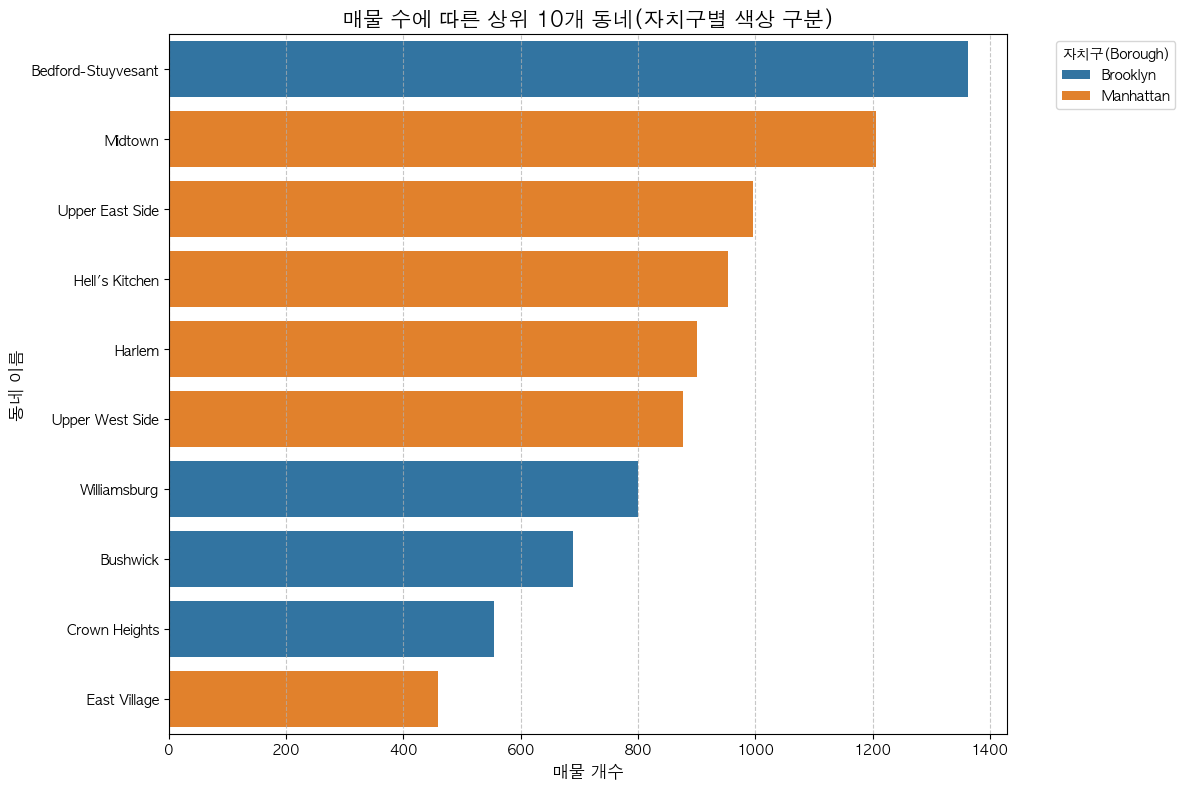

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False #마이너스 기호 깨짐 방지

#데이터 : 아까 만든 top10_result 활용
plt.figure(figsize=(12, 8))

#막대 그래프(x축: 매물 수, y축: 동네이름)
sns.barplot(
    data=top10_result, 
    x='count', 
    y='neighbourhood_cleansed', 
    hue='neighbourhood_group_cleansed',
    dodge=False #dodge를 사용하면 막대가 갈라지지 않게 설정
)

plt.title('매물 수에 따른 상위 10개 동네(자치구별 색상 구분)', fontsize=15)
plt.xlabel('매물 개수', fontsize=12)
plt.ylabel('동네 이름', fontsize=12)
plt.legend(title='자치구(Borough)', bbox_to_anchor=(1.05, 1), loc='upper left') 
#범례 위치를 보기 좋게 조절
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 숙소 및 방 타입 믹스 (Room/Property Type)

In [8]:
#숙소 타입 관련 컬럼 데이터 점검
type_cols = ['room_type', 'property_type']

# 데이터 타입 및 결측치 확인
print(df[type_cols].info())
print("\n[결측치 개수]")
print(df[type_cols].isnull().sum())

#Room Type별 실제 개수 확인
print("\n[Room Type 종류 및 개수]")
print(df['room_type'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 19861 entries, 0 to 19860
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   room_type      19861 non-null  str  
 1   property_type  19861 non-null  str  
dtypes: str(2)
memory usage: 310.5 KB
None

[결측치 개수]
room_type        0
property_type    0
dtype: int64

[Room Type 종류 및 개수]
room_type
Entire home/apt    10797
Private room        8704
Hotel room           360
Name: count, dtype: int64


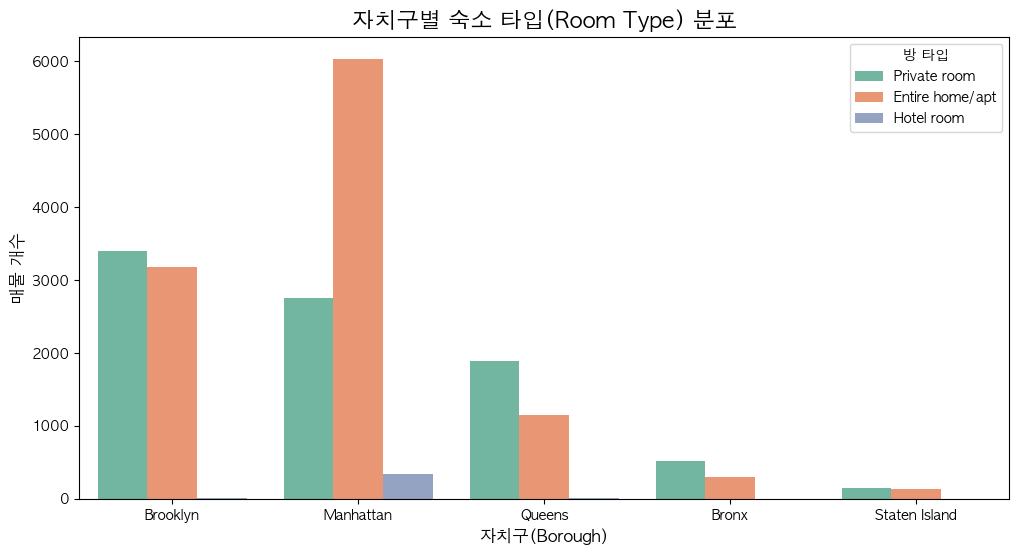

In [9]:
#자치구별로 방 타입의 비중이 어떻게 다를지..
#맨해튼은 집 전체가 많을지? 그리고 브루클린은 개인실이 많을지? 이런 가설을 세워볼 수 있을 것 같음
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

#자치구별 Room Type 분포(Stacked 혹은 Grouped Bar로 표현)
sns.countplot(data=df, x='neighbourhood_group_cleansed', hue='room_type', palette='Set2')
#둘 다 해본 결과 grouped bar가 더 보기 좋게 나와서 이걸로 결정

plt.title('자치구별 숙소 타입(Room Type) 분포', fontsize=16)
plt.xlabel('자치구(Borough)', fontsize=12)
plt.ylabel('매물 개수', fontsize=12)
plt.legend(title='방 타입', bbox_to_anchor=(1, 1))
plt.show()
#Manhattan : 진짜 Entire home 막대가 압도적으로 높음.
#Brooklyn : private home이 가장 많음, 그리고 hotel room은 거의 없음.

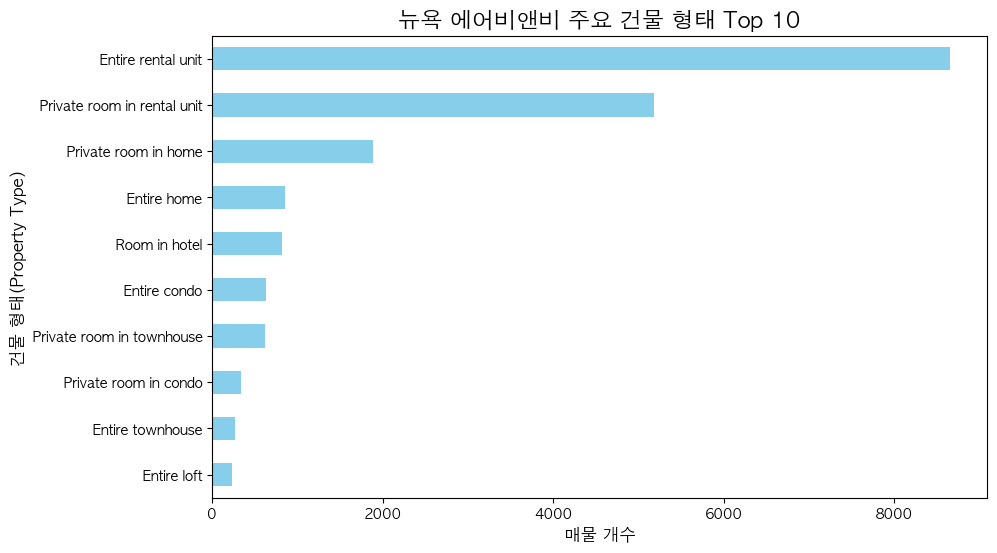

In [10]:
#room_type보다 더 구체적인 건물타입 property_type
#property_tepe에서 상위 10개 건물 형태 추출
top10_property = df['property_type'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top10_property.plot(kind='barh', color='skyblue')

plt.title('뉴욕 에어비앤비 주요 건물 형태 Top 10', fontsize=16)
plt.xlabel('매물 개수', fontsize=12)
plt.ylabel('건물 형태(Property Type)', fontsize=12)
plt.gca().invert_yaxis() #높은 순서가 위로 오게끔
plt.show()
#Manhattan : Entire home/apt 비중이 약 6,000건으로 압도적 / 관광 중심지로 프라이버시를 중시하는 독채형 공급이 시장을 주도
#Brooklyn : Private room과 Entire home/apt 비중이 약 3,000건 초반대로 팽팽하게 대립 / 주거와 관광 특성이 혼합된 하이브리드 시장
#Queens : Entire home/apt 보다 Private room 비중이 훨씬 높게 나타남 / 가성비 위주의 숙박 및 장기 체류형 공급이 활발한 지역
#Bronx / Staten Island : 절대적인 매물 수는 적으나, 대부분 Private room 위주로 형성

1. Manhattan : Entire home/apt 비중이 약 6,000건으로 압도적 / 관광 중심지로 프라이버시를 중시하는 독채형 공급이 시장을 주도

2. Brooklyn : Private room과 Entire home/apt 비중이 약 3,000건 초반대로 팽팽하게 대립 / 주거와 관광 특성이 혼합된 하이브리드 시장

3. Queens : Entire home/apt 보다 Private room 비중이 훨씬 높게 나타남 / 가성비 위주의 숙박 및 장기 체류형 공급이 활발한 지역

4. Bronx / Staten Island : 절대적인 매물 수는 적으나, 대부분 Private room 위주로 형성

#### 단기 vs 장기 비중 (30Day 현황)

[30일 규제 집중도 분석 결과]
뉴욕 전체 매물: 19861개
30일로 설정된 매물: 15582개
전체 시장 내 비중: 78.5%


/var/folders/gl/8lvzdtwj3y16x6_c0dm1mj9c0000gn/T/ipykernel_4828/1267275693.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


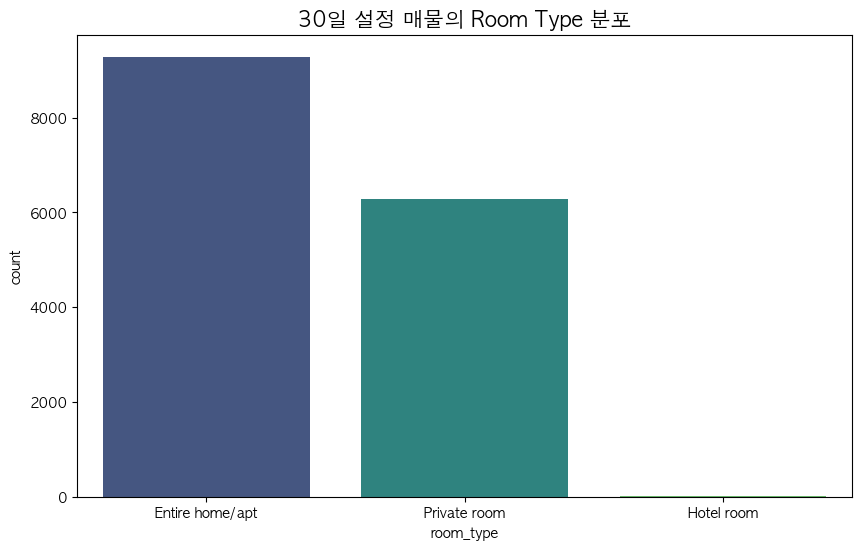

/var/folders/gl/8lvzdtwj3y16x6_c0dm1mj9c0000gn/T/ipykernel_4828/1267275693.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


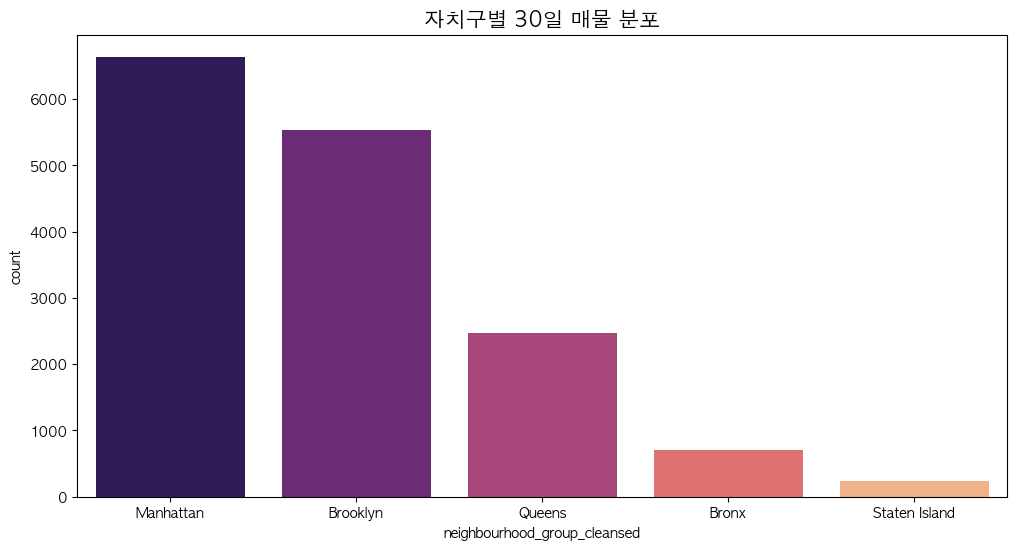

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

df_30 = df[df['minimum_nights'] == 30]
total_count = len(df)
count_30 = len(df_30)
ratio_30 = (count_30 / total_count) * 100

print(f"[30일 규제 집중도 분석 결과]")
print(f"뉴욕 전체 매물: {total_count}개")
print(f"30일로 설정된 매물: {count_30}개")
print(f"전체 시장 내 비중: {ratio_30:.1f}%")

#30일 매물의 Room Type 분포
#규제가 엄격한 'Entire home/apt'가 얼마나 많은지 보는 게 핵심
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_30, 
    x='room_type', 
    palette='viridis', 
    order=df_30['room_type'].value_counts().index
)
plt.title('30일 설정 매물의 Room Type 분포', fontsize=15)
plt.show()

#자치구별 30일 매물 현황
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_30, 
    x='neighbourhood_group_cleansed', 
    palette='magma',
    order=df_30['neighbourhood_group_cleansed'].value_counts().index
)
plt.title('자치구별 30일 매물 분포', fontsize=15)
plt.show()
#뉴욕 30일 규제 분석 브리핑
#시장의 기형적 쏠림 (78.5%)
#뉴욕 전체 매물 19,861개 중 무려 15,582개(78.5%)가 '최소 숙박 30일'로 설정
#이건 호스트들의 자발적 선택이 아니라, Local Law 18에 대응하기 위한 생존 전략임을 알 수 있음
#-> 뉴욕 에어비앤비는 이제 여행자 숙소가 아니라 장기 임대 시장으로 변했다고 볼 수 있음

In [12]:
df['property_regulation_type'].value_counts()

property_regulation_type
Residential_long_term     17245
Residential_short_term     1590
Hotel                      1026
Name: count, dtype: int64

/var/folders/gl/8lvzdtwj3y16x6_c0dm1mj9c0000gn/T/ipykernel_4828/2727033536.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='reviews_per_month', data=filtered_df, palette='Set2')


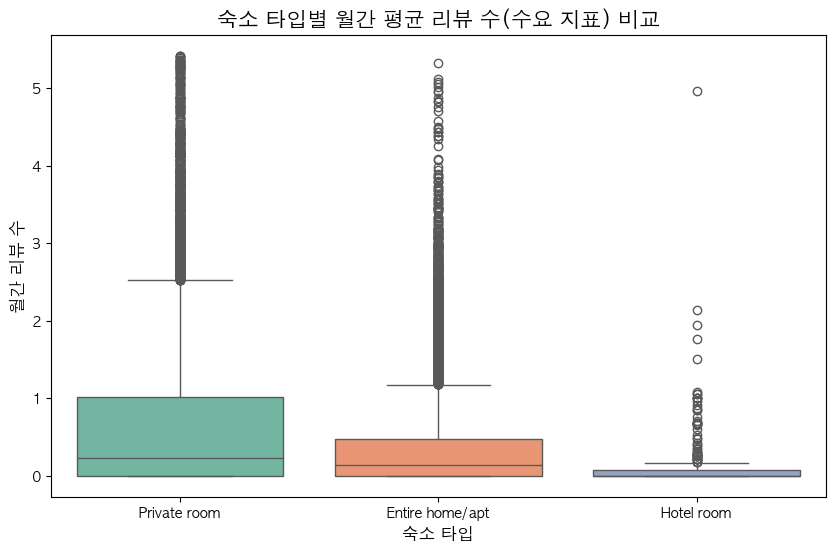

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='AppleGothic') 

#이상치를 제외한 데이터 필터링 (너무 리뷰가 많은 상위 1% 제외)
limit_review = df['reviews_per_month'].quantile(0.99)
filtered_df = df[df['reviews_per_month'] < limit_review]

#시각화 (Boxplot + Stripplot 합치기)
plt.figure(figsize=(10, 6))

#박스플롯으로 분포 확인
sns.boxplot(x='room_type', y='reviews_per_month', data=filtered_df, palette='Set2')

#실제 데이터 점들을 활용하여 밀집도 확인 (이건 llm에게 가독성을 위해 물어본 내용입니다!)
# sns.stripplot(x='room_type', y='reviews_per_month', data=filtered_df, color='black', alpha=0.1)

plt.title('숙소 타입별 월간 평균 리뷰 수(수요 지표) 비교', fontsize=15)
plt.xlabel('숙소 타입', fontsize=12)
plt.ylabel('월간 리뷰 수', fontsize=12)
plt.show()